In [29]:
library(car)
library(caret)
library(glmnet)
library(tidyr)
library(corrplot)
library(arm)
library(MASS)
library(pscl)
source("config.R")

Classes and Methods for R originally developed in the
Political Science Computational Laboratory
Department of Political Science
Stanford University (2002-2015),
by and under the direction of Simon Jackman.
hurdle and zeroinfl functions by Achim Zeileis.



# Data

## Dataset Overview

In [2]:
bike.data <- read.csv(DAY_DATA)

str(bike.data)

'data.frame':	731 obs. of  16 variables:
 $ instant   : int  1 2 3 4 5 6 7 8 9 10 ...
 $ dteday    : chr  "2011-01-01" "2011-01-02" "2011-01-03" "2011-01-04" ...
 $ season    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ yr        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ mnth      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ holiday   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ weekday   : int  6 0 1 2 3 4 5 6 0 1 ...
 $ workingday: int  0 0 1 1 1 1 1 0 0 1 ...
 $ weathersit: int  2 2 1 1 1 1 2 2 1 1 ...
 $ temp      : num  0.344 0.363 0.196 0.2 0.227 ...
 $ atemp     : num  0.364 0.354 0.189 0.212 0.229 ...
 $ hum       : num  0.806 0.696 0.437 0.59 0.437 ...
 $ windspeed : num  0.16 0.249 0.248 0.16 0.187 ...
 $ casual    : int  331 131 120 108 82 88 148 68 54 41 ...
 $ registered: int  654 670 1229 1454 1518 1518 1362 891 768 1280 ...
 $ cnt       : int  985 801 1349 1562 1600 1606 1510 959 822 1321 ...


In [3]:
result.na <- data.frame(
  Total_Observations = nrow(bike.data),
  Missing_Values     = sum(is.na(bike.data))
)
print(result.na, row.names = FALSE)


 Total_Observations Missing_Values
                731              0


In [4]:
preprocess <- function(df) {
  df$instant    <- NULL
  df$dteday     <- NULL
  df$casual     <- NULL
  df$registered <- NULL
  
  df$season     <- factor(df$season, levels = 1:4,
                          labels = c("Winter", "Spring", "Summer", "Fall"))
  df$yr         <- as.factor(df$yr)
  df$mnth       <- as.factor(df$mnth)
  df$holiday    <- factor(df$holiday,    levels = c(0, 1))
  df$weekday    <- factor(df$weekday,    levels = 0:6)
  df$workingday <- factor(df$workingday, levels = c(0, 1))
  df$weathersit <- as.factor(df$weathersit)
  
  return(df)
}

bike.data <- preprocess(bike.data)

In [5]:
check_missing <- function(df, df.name = "") {
  missing.idx <- which(!complete.cases(df))
  cat(df.name, ": Found", length(missing.idx), "missing rows\n")
  if (length(missing.idx) > 0) print(df[missing.idx, ], row.names = FALSE)
  invisible(missing.idx)
}

check_missing(bike.data, "bike.data")

bike.data : Found 0 missing rows


# Exploratory Data Analysis

## Feature Distribution

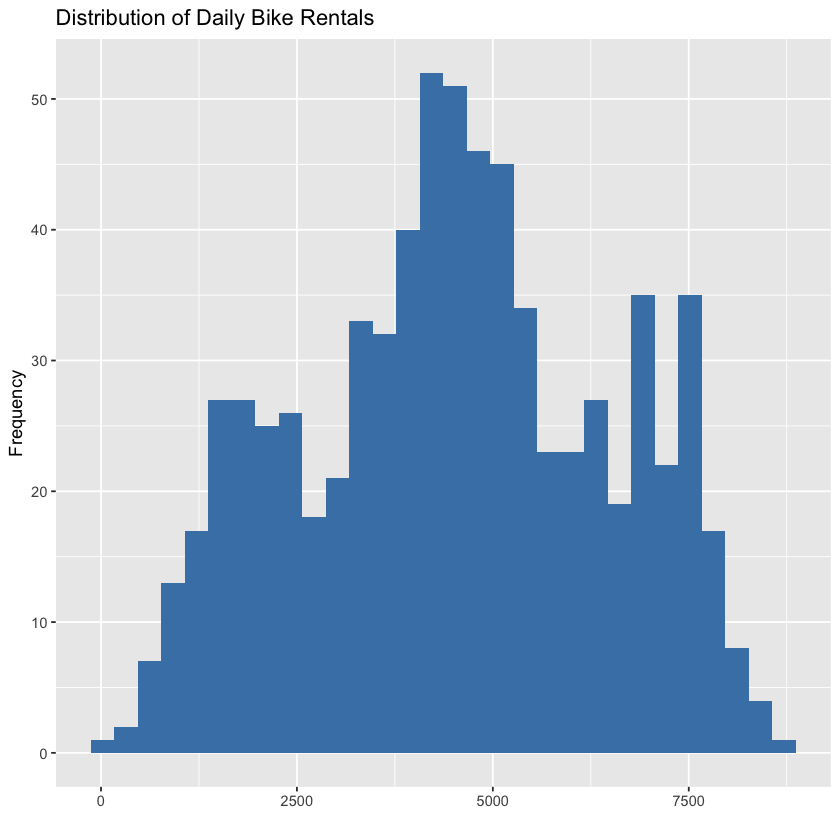

In [6]:
ggplot(bike.data, aes(x = cnt)) +
  geom_histogram(fill = "steelblue", bins = 30) +
  labs(title = "Distribution of Daily Bike Rentals",
       x = "", y = "Frequency")

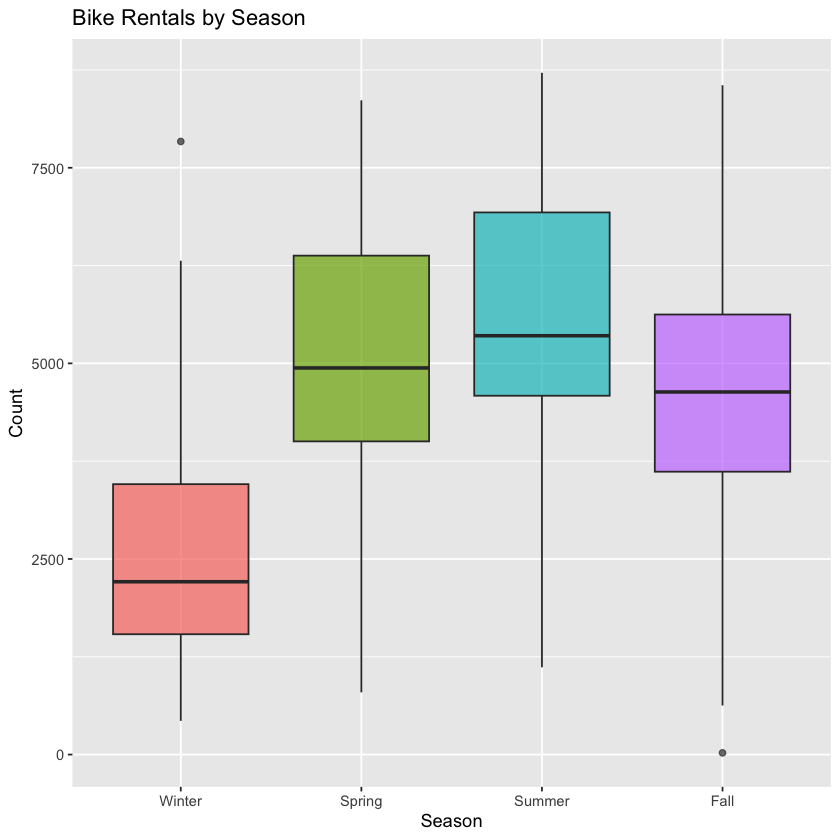

In [7]:
ggplot(bike.data, aes(x = season, y = cnt, fill = season)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Bike Rentals by Season", x = "Season", y = "Count") +
  theme(legend.position = "none")

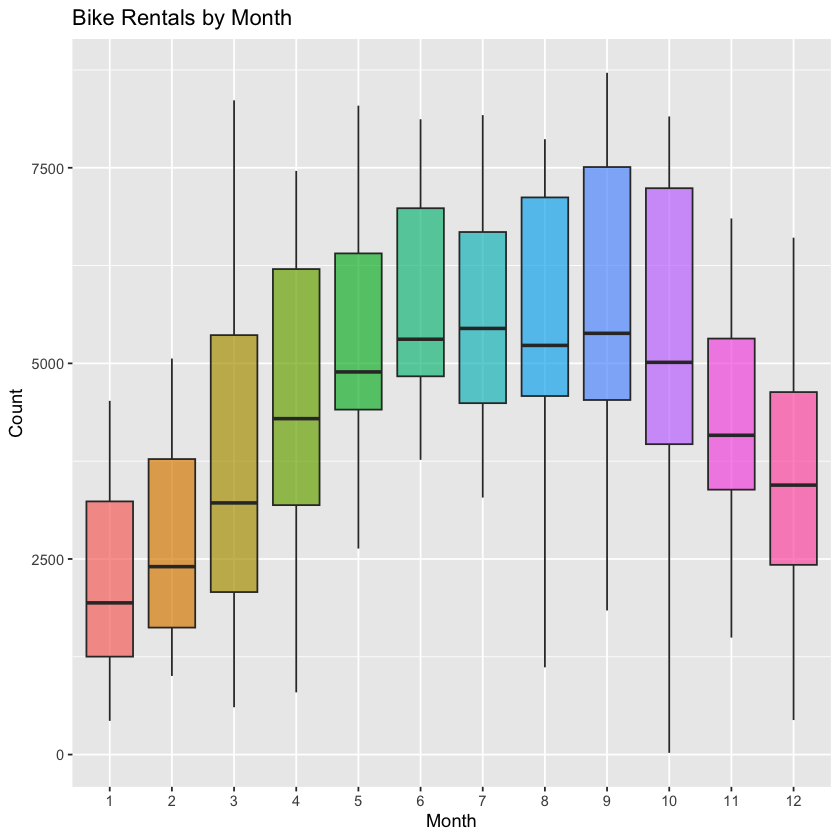

In [8]:
ggplot(bike.data, aes(x = mnth, y = cnt, fill = mnth)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Bike Rentals by Month", x = "Month", y = "Count") +
  theme(legend.position = "none")

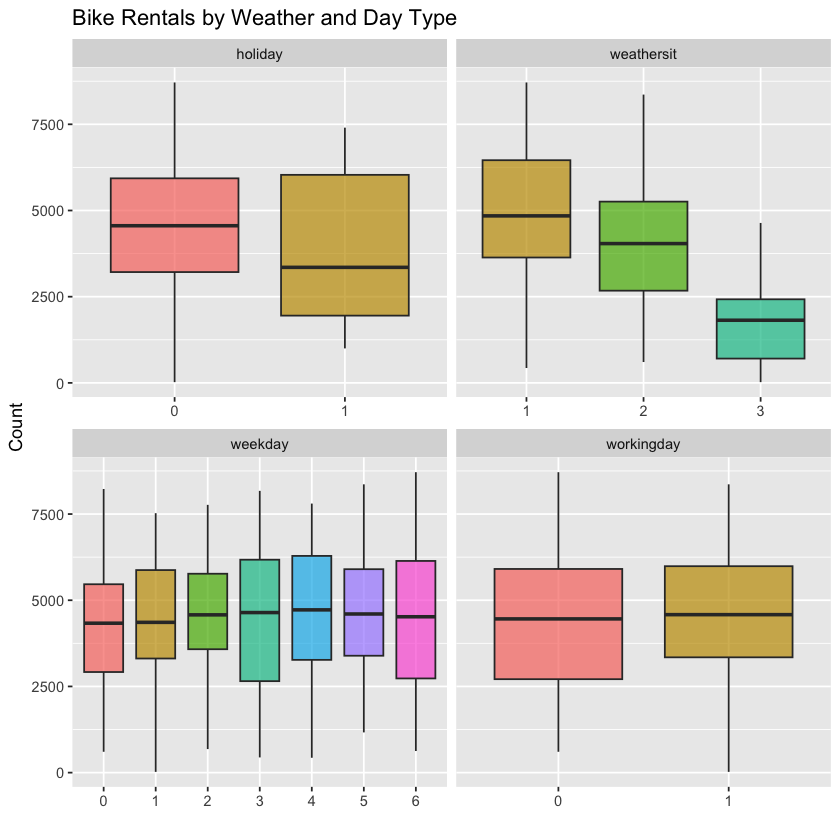

In [9]:
cat.group2 <- c("weathersit", "holiday", "weekday", "workingday")

df.cat2 <- pivot_longer(
  data = bike.data[, c("cnt", cat.group2)],
  cols = -cnt,
  names_to = "feature",
  values_to = "value",
  values_transform = list(value = as.character)
)

df.cat2$value <- factor(df.cat2$value,
                        levels = as.character(sort(unique(as.numeric(df.cat2$value)))))

ggplot(df.cat2, aes(x = value, y = cnt, fill = value)) +
  geom_boxplot(alpha = 0.7) +
  facet_wrap(~feature, scales = "free_x") +
  labs(title = "Bike Rentals by Weather and Day Type",
       x = "", y = "Count") +
  theme(legend.position = "none")

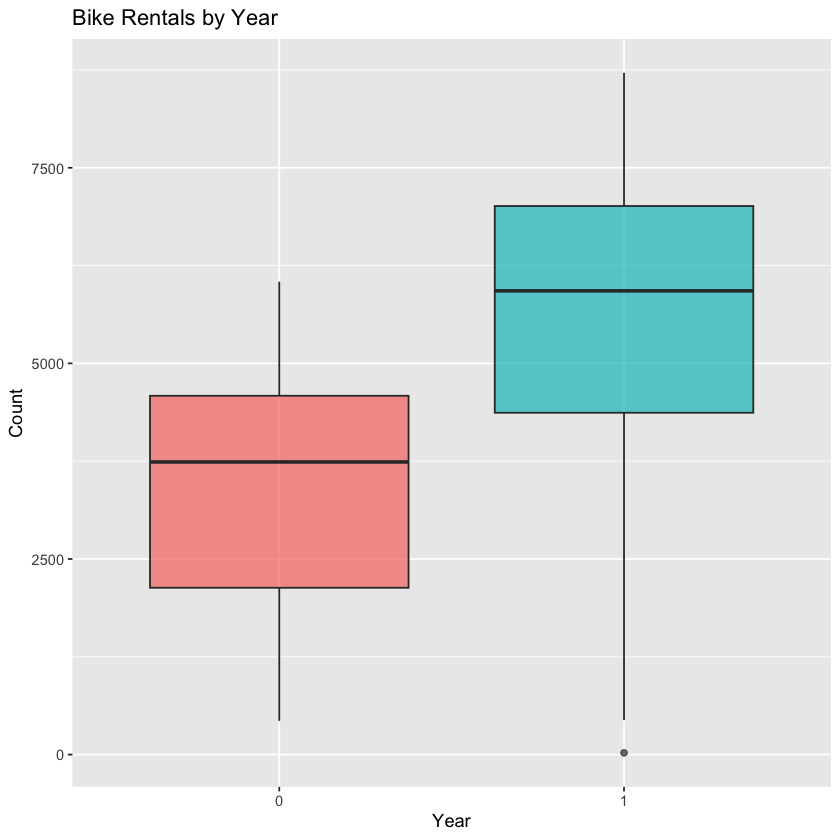

In [10]:
ggplot(bike.data, aes(x = yr, y = cnt, fill = yr)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Bike Rentals by Year", x = "Year", y = "Count") +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'


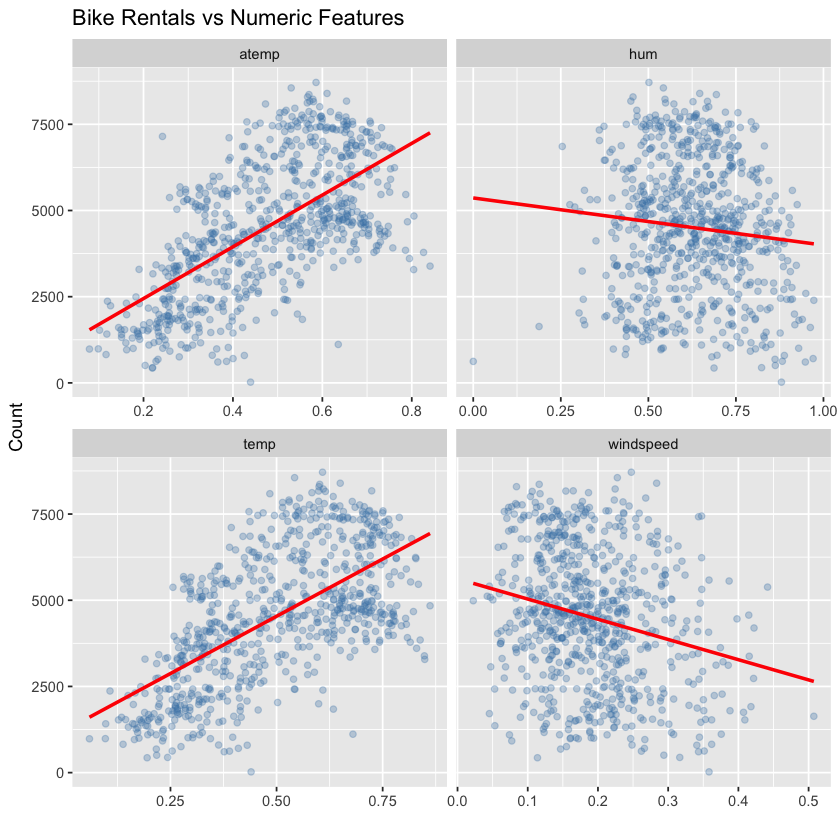

In [11]:
numeric.features <- c("temp", "atemp", "hum", "windspeed")

df.num.long <- pivot_longer(data = bike.data[, c("cnt", numeric.features)],
                            cols = -cnt,
                            names_to = "feature",
                            values_to = "value")

ggplot(df.num.long, aes(x = value, y = cnt)) +
  geom_point(alpha = 0.3, color = "steelblue") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~feature, scales = "free_x") +
  labs(title = "Bike Rentals vs Numeric Features",
       x = "", y = "Count")

## Feature Correlation

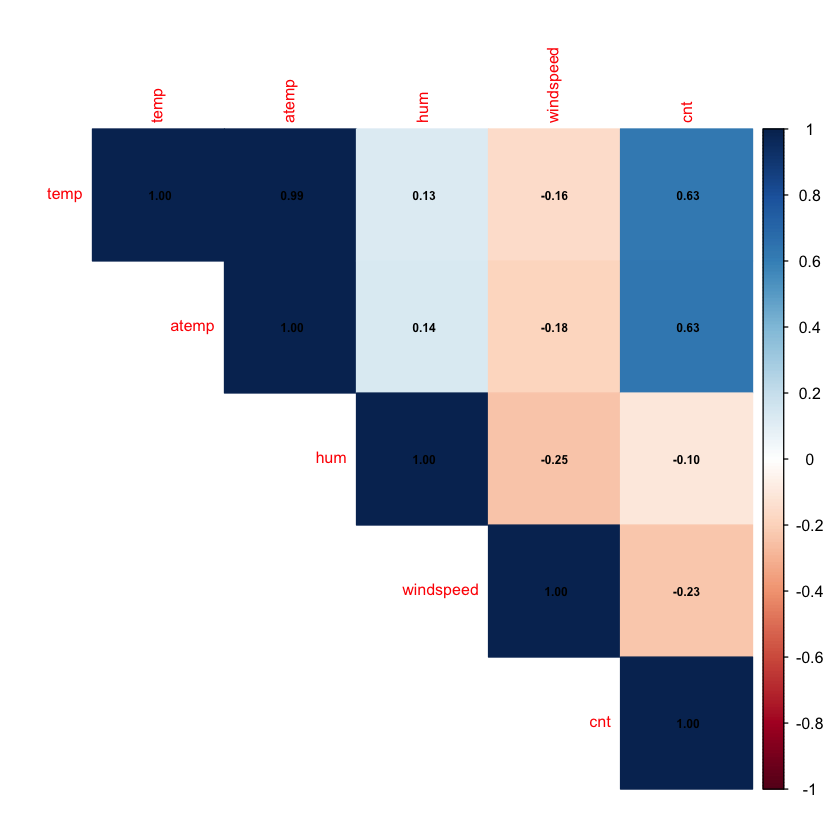

In [12]:
numeric.features <- c("temp", "atemp", "hum", "windspeed", "cnt")
cor.data <- bike.data[, numeric.features]

corrplot(cor(cor.data, use = "complete.obs"),
    method = "color",
    type = "upper",
    tl.cex = 0.8, 
    addCoef.col = "black",
    number.cex = 0.6)

## Multicollinearity Check (VIF)

In [13]:
compute_vif <- function(data) {
  lm.proxy <- lm(cnt ~ . - atemp - mnth - workingday, data = data)
  vif.result <- vif(lm.proxy)
  vif.data <- data.frame(
    Feature = rownames(vif.result),
    VIF     = round(vif.result[, 1], 3)
  )
  print(vif.data, row.names = FALSE)
  invisible(vif.data)
}

compute_vif(bike.data)

    Feature   VIF
     season 3.542
         yr 1.031
    holiday 1.092
    weekday 1.132
 weathersit 1.828
       temp 3.414
        hum 1.930
  windspeed 1.190


# Methodology

## Poisson GLM

### Dispersion Check

In [14]:
result.dispersion <- data.frame(
  Metric = c("Mean", "Variance", "Variance/Mean Ratio"),
  Value  = c(mean(bike.data$cnt), var(bike.data$cnt), var(bike.data$cnt) / mean(bike.data$cnt))
)
print(result.dispersion, row.names = FALSE)

              Metric        Value
                Mean    4504.3488
            Variance 3752788.2083
 Variance/Mean Ratio     833.1478


### Coefficients and IRR Table

In [16]:
poisson.model <- glm(cnt ~ season + yr + holiday + weekday + 
                     weathersit + temp + hum + windspeed,
                     data = bike.data,
                     family = poisson(link = "log"))

In [18]:
result.irr <- data.frame(
  Variable = names(coef(poisson.model)),
  IRR      = round(exp(coef(poisson.model)), 3),
  CI_Lower = round(exp(confint(poisson.model))[, 1], 3),
  CI_Upper = round(exp(confint(poisson.model))[, 2], 3)
)

print(result.irr, row.names = FALSE)

Waiting for profiling to be done...



Waiting for profiling to be done...



     Variable      IRR CI_Lower CI_Upper
  (Intercept) 1759.158 1743.266 1775.192
 seasonSpring    1.411    1.405    1.417
 seasonSummer    1.288    1.280    1.295
   seasonFall    1.589    1.583    1.595
          yr1    1.583    1.580    1.587
     holiday1    0.835    0.828    0.841
     weekday1    1.057    1.053    1.062
     weekday2    1.071    1.067    1.075
     weekday3    1.071    1.066    1.075
     weekday4    1.084    1.080    1.088
     weekday5    1.092    1.088    1.097
     weekday6    1.098    1.093    1.102
  weathersit2    0.899    0.897    0.902
  weathersit3    0.476    0.471    0.481
         temp    3.375    3.338    3.413
          hum    0.799    0.790    0.808
    windspeed    0.566    0.557    0.575


In [19]:
dispersion <- poisson.model$deviance / poisson.model$df.residual
cat("Residual Deviance:", poisson.model$deviance, "\n")
cat("Degrees of Freedom:", poisson.model$df.residual, "\n")
cat("Dispersion Estimate:", dispersion, "\n")

Residual Deviance: 130373.8 
Degrees of Freedom: 714 
Dispersion Estimate: 182.5964 


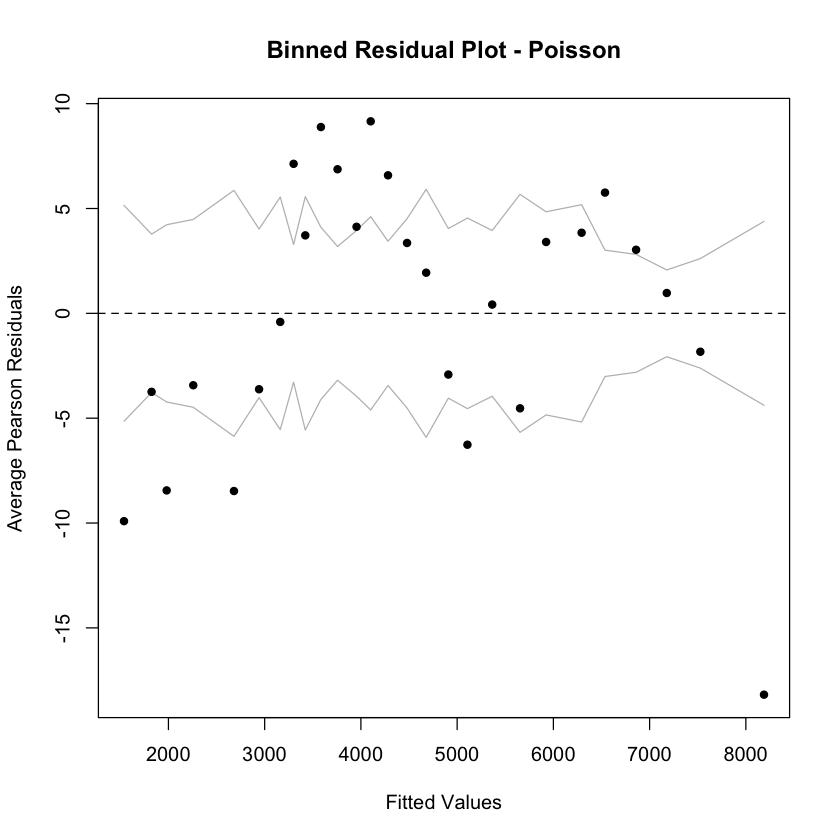

In [21]:
binnedplot(fitted(poisson.model),
           resid(poisson.model, type = "pearson"),
           main = "Binned Residual Plot - Poisson",
           xlab = "Fitted Values",
           ylab = "Average Pearson Residuals")

## Negative Binomial 

In [25]:
nb.model <- glm.nb(cnt ~ season + yr + holiday + weekday + 
                   weathersit + temp + hum + windspeed,
                   data = bike.data)

summary(nb.model)


Call:
glm.nb(formula = cnt ~ season + yr + holiday + weekday + weathersit + 
    temp + hum + windspeed, data = bike.data, init.theta = 16.63488969, 
    link = log)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)   7.37348    0.07055 104.507  < 2e-16 ***
seasonSpring  0.32864    0.03396   9.677  < 2e-16 ***
seasonSummer  0.22234    0.04484   4.958 7.12e-07 ***
seasonFall    0.48022    0.02891  16.609  < 2e-16 ***
yr1           0.48155    0.01846  26.085  < 2e-16 ***
holiday1     -0.21173    0.05688  -3.723 0.000197 ***
weekday1      0.06506    0.03493   1.862 0.062574 .  
weekday2      0.08247    0.03414   2.416 0.015713 *  
weekday3      0.07277    0.03422   2.126 0.033464 *  
weekday4      0.09459    0.03420   2.765 0.005685 ** 
weekday5      0.11528    0.03421   3.370 0.000752 ***
weekday6      0.08950    0.03402   2.631 0.008522 ** 
weathersit2  -0.10274    0.02437  -4.215 2.49e-05 ***
weathersit3  -0.72785    0.06244 -11.657  < 2e-16 ***
temp    

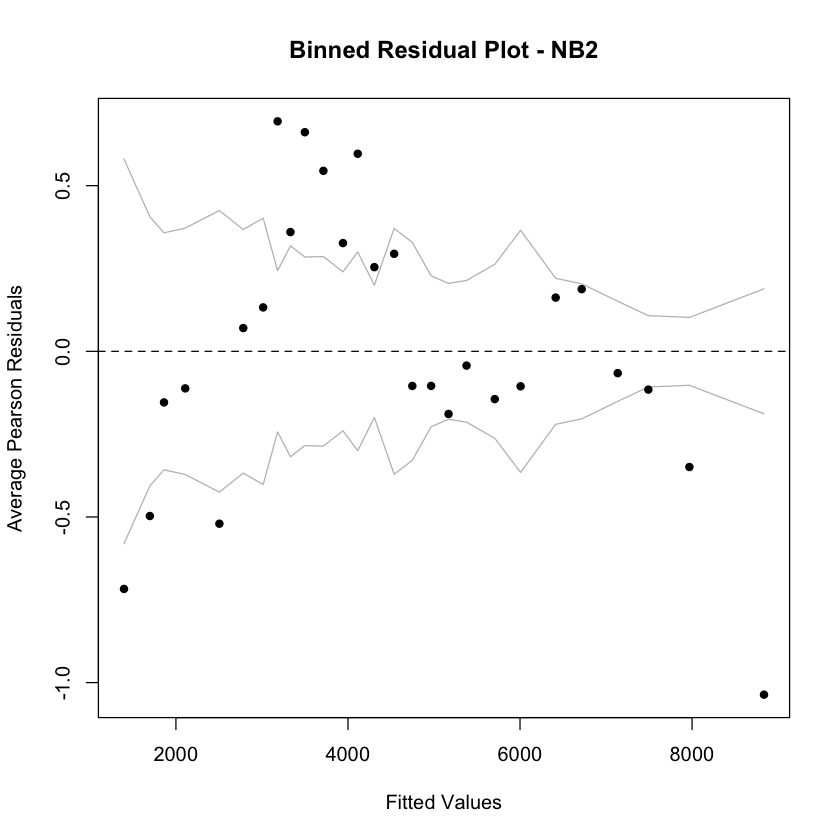

In [26]:
binnedplot(fitted(nb.model),
           resid(nb.model, type = "pearson"),
           main = "Binned Residual Plot - NB2",
           xlab = "Fitted Values",
           ylab = "Average Pearson Residuals")

## Zero-Inflated Poisson (ZIP)

In [ ]:
zip.model <- zeroinfl(cnt ~ season + yr + holiday + weekday +
                      weathersit + temp + hum + windspeed,
                      data = bike.data,
                      dist = "poisson")

summary(zip.model)

ERROR: Error in zeroinfl(cnt ~ season + yr + holiday + weekday + weathersit + : invalid dependent variable, minimum count is not zero
